In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("14-income_evaluation.csv")

In [3]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14   income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
df.isnull().sum()

age                0
 workclass         0
 fnlwgt            0
 education         0
 education-num     0
 marital-status    0
 occupation        0
 relationship      0
 race              0
 sex               0
 capital-gain      0
 capital-loss      0
 hours-per-week    0
 native-country    0
 income            0
dtype: int64

In [6]:
df.shape

(32561, 15)

In [7]:
df.columns = df.columns.str.strip()

In [8]:
for col in df.columns:
    print(df[col].value_counts())

age
36    898
31    888
34    886
23    877
35    876
     ... 
83      6
88      3
85      3
86      1
87      1
Name: count, Length: 73, dtype: int64
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
fnlwgt
164190    13
203488    13
123011    13
148995    12
121124    12
          ..
232784     1
325573     1
140176     1
318264     1
257302     1
Name: count, Length: 21648, dtype: int64
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

In [9]:
for col in df.columns:
    if df[col].dtype == 'object':
        count = (df[col].str.strip() == '?').sum()
        if count > 0:
            print(f"{col}: {count} '?'")

workclass: 1836 '?'
occupation: 1843 '?'
native-country: 583 '?'


In [10]:
df.replace(['?', ' ?'], np.nan, inplace=True)
df.dropna(inplace=True)

In [11]:
# Drop 'education' to avoid multicollinearity (keeping the numeric 'education-num' instead)
df.drop('education', axis=1, inplace=True)

In [12]:
# Encode target variable for machine learning compatibility
df['income'] = df['income'].str.strip().map({'<=50K': 0, '>50K': 1})

In [13]:
df.reset_index(drop=True, inplace=True)

In [14]:
df.shape

(30162, 14)

In [15]:
df.head()

,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


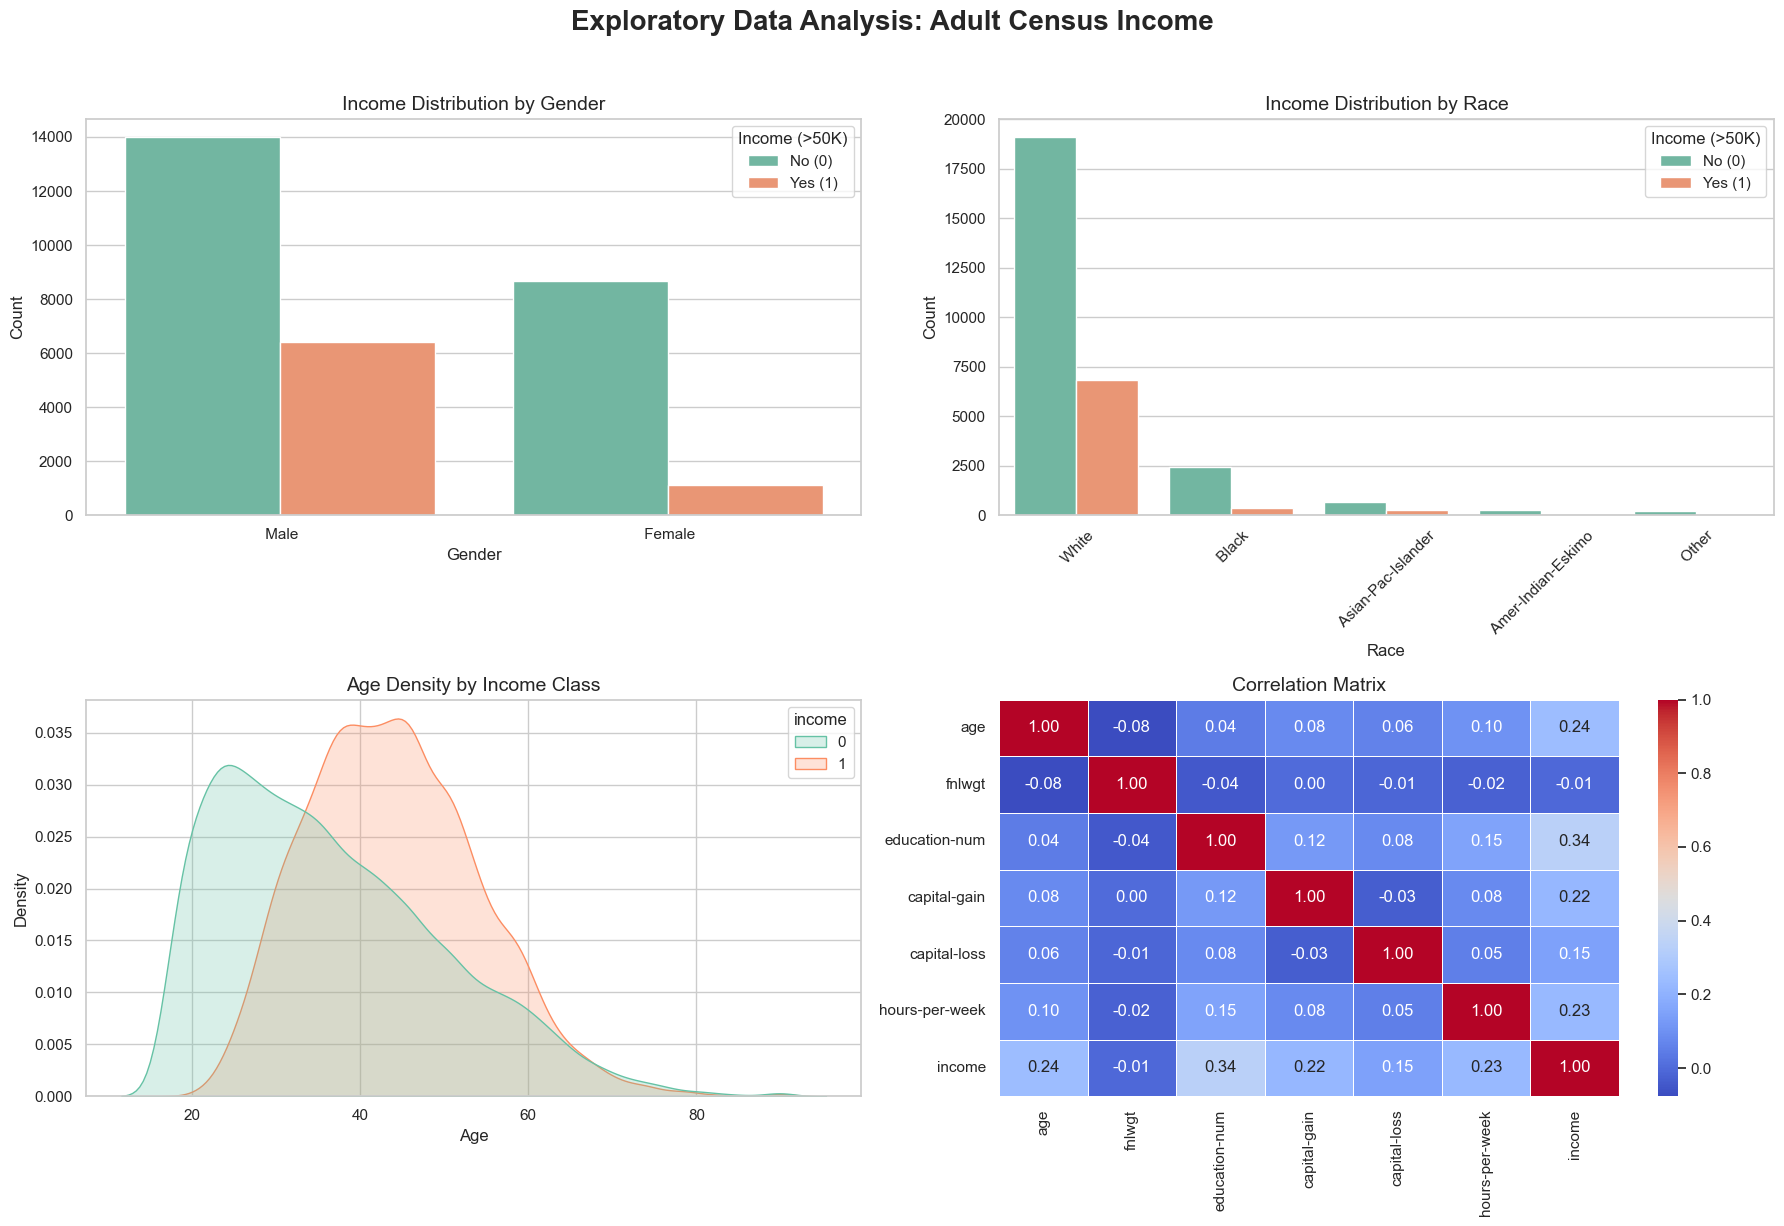

In [16]:
# Set a professional and clean visual theme for all plots
sns.set_theme(style="whitegrid", palette="muted")

# Create a figure with subplots (2 rows, 2 columns) to display everything neatly
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Exploratory Data Analysis: Adult Census Income', fontsize=20, fontweight='bold', y=1.02)

# 1. Income Distribution by Sex
# Highlights potential gender bias/gap in earning >50K. 
sns.countplot(ax=axes[0, 0], data=df, x='sex', hue='income', palette='Set2')
axes[0, 0].set_title('Income Distribution by Gender', fontsize=14)
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(title='Income (>50K)', labels=['No (0)', 'Yes (1)'])

# 2. Income Distribution by Race
# Explores socio-economic patterns across different racial groups.
sns.countplot(ax=axes[0, 1], data=df, x='race', hue='income', palette='Set2')
axes[0, 1].set_title('Income Distribution by Race', fontsize=14)
axes[0, 1].set_xlabel('Race')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45) # Rotate labels for better readability
axes[0, 1].legend(title='Income (>50K)', labels=['No (0)', 'Yes (1)'])

# 3. Age vs Income (KDE Plot)
# Shows the density of age distribution for both income classes. 
# Usually reveals that middle-aged professionals are more likely to earn >50K.
sns.kdeplot(ax=axes[1, 0], data=df, x='age', hue='income', fill=True, common_norm=False, palette='Set2')
axes[1, 0].set_title('Age Density by Income Class', fontsize=14)
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Density')

# 4. Correlation Heatmap (Numeric Variables Only)
# Crucial for identifying multicollinearity and strong predictors before feeding data to ML models.
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(ax=axes[1, 1], data=df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
axes[1, 1].set_title('Correlation Matrix', fontsize=14)

# Adjust layout to prevent overlapping text
plt.tight_layout()
plt.show()

In [17]:
df.head()

,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [19]:
# FEATURE ENGINEERING & HANDLING RARE CATEGORIES
# Grouping rare categories to prevent near-zero variance issues and reduce noise

# Group 'native-country' to prevent extreme dimensionality (curse of dimensionality)
df['native-country'] = df['native-country'].apply(lambda x: 'United-States' if x.strip() == 'United-States' else 'Other')

# Merge sparse 'workclass' categories into a broader group
df['workclass'] = df['workclass'].replace(['Without-pay', 'Never-worked'], 'Other')

# Merge 'Married-AF-spouse' (Armed Forces) with the general married category
df['marital-status'] = df['marital-status'].replace(['Married-AF-spouse'], 'Married-civ-spouse')

# Merge extremely rare occupations into broader service categories
df['occupation'] = df['occupation'].replace(['Armed-Forces', 'Priv-house-serv'], 'Other-service')

In [20]:
# SKEWNESS TREATMENT (Log Transformation)
# Apply log(x+1) to highly right-skewed features ('capital-gain', 'capital-loss').
# This minimizes the impact of extreme outliers (like 99999) on distance-based models (e.g., SVM, Logistic Regression).
df['capital-gain'] = np.log1p(df['capital-gain'])
df['capital-loss'] = np.log1p(df['capital-loss'])

In [21]:
# ONE-HOT ENCODING
# Convert nominal categorical variables into numeric dummy variables.
# drop_first=True prevents the "dummy variable trap" (perfect multicollinearity).
categorical_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [22]:
# Ensure all data is in standard numeric format for ML models
df = df.astype(float)
df['income'] = df['income'].astype(int)

In [23]:
df.reset_index(drop=True, inplace=True)

In [25]:
df.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,...,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Male,native-country_United-States
0,39.0,77516.0,13.0,7.684784,0.0,40.0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
1,50.0,83311.0,13.0,0.000000,0.0,13.0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
2,38.0,215646.0,9.0,0.000000,0.0,40.0,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
3,53.0,234721.0,7.0,0.000000,0.0,40.0,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
4,28.0,338409.0,13.0,0.000000,0.0,40.0,0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [27]:
X = df.drop('income', axis=1)
y = df['income']

In [29]:
# stratify=y is CRITICAL here due to our class imbalance (75% <=50K, 25% >50K).
# It ensures both train and test sets maintain this exact same ratio.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Training features shape: (24129, 42)
Testing features shape: (6033, 42)


In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [33]:
rf_baseline = RandomForestClassifier(random_state=42)

In [34]:
rf_baseline.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
y_pred_rf = rf_baseline.predict(X_test_scaled)

In [36]:
print("--- Random Forest (Baseline) Performance ---\n")
print(classification_report(y_test, y_pred_rf))

--- Random Forest (Baseline) Performance ---

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4531
           1       0.74      0.62      0.67      1502

    accuracy                           0.85      6033
   macro avg       0.81      0.77      0.79      6033
weighted avg       0.84      0.85      0.85      6033



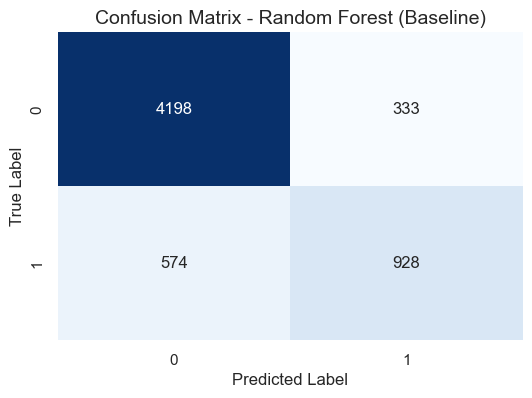

In [37]:
#VISUALIZE THE CONFUSION MATRIX
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Random Forest (Baseline)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

In [38]:
from sklearn.model_selection import RandomizedSearchCV

In [39]:
# DEFINE THE HYPERPARAMETER GRID
rf_tuning = RandomForestClassifier(random_state=42)
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500], # Number of trees in the forest
    'max_depth': [10, 12, 15, 20],       # Maximum depth of the tree to prevent overfitting
    'min_samples_split': [2, 5, 10],           # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],             # Minimum number of samples required to be at a leaf node
    'class_weight': ['balanced', 'balanced_subsample', None] # CRITICAL: Penalizes the model heavily for missing the minority class
}

# SET UP RANDOMIZED SEARCH CV
# n_iter=20 means it will randomly try 20 different combinations (keeps execution time reasonable).
# cv=5 means 5-fold cross-validation.
# scoring='f1' ensures the algorithm optimizes for the minority class, not just general accuracy.
random_search = RandomizedSearchCV(
    estimator=rf_tuning, 
    param_distributions=param_dist, 
    n_iter=20, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1, # Uses all available CPU cores to speed up the process
    random_state=42,
    verbose=2  # Prints progress logs
)

print("Starting Hyperparameter Tuning... This may take a moment.")
random_search.fit(X_train_scaled, y_train)

# RETRIEVE AND EVALUATE THE BEST MODEL
best_rf_model = random_search.best_estimator_

print("\n--- Best Hyperparameters Found ---")
print(random_search.best_params_)

# Make predictions with the optimized model
y_pred_best_rf = best_rf_model.predict(X_test_scaled)

print("\n--- Optimized Random Forest Performance ---")
print(classification_report(y_test, y_pred_best_rf))

Starting Hyperparameter Tuning... This may take a moment.
Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- Best Hyperparameters Found ---
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 20, 'class_weight': 'balanced_subsample'}

--- Optimized Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4531
           1       0.61      0.82      0.70      1502

    accuracy                           0.83      6033
   macro avg       0.77      0.82      0.79      6033
weighted avg       0.85      0.83      0.83      6033



In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
import time

In [43]:
# 1. INITIALIZE THE MODELS
# We apply class_weight='balanced' where applicable to handle our 75/25 class imbalance fairly.
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Support Vector Machine': SVC(class_weight='balanced', random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# 2. CREATE AN EMPTY LIST TO STORE RESULTS
results = []

print("Starting the Model Showdown! This might take a few minutes (especially SVM)...\n")

# 3. TRAIN AND EVALUATE IN A LOOP
for model_name, model in models.items():
    start_time = time.time()
    print(f"Training {model_name}...")
    
    # Fit the model on the scaled training data
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics specifically for the minority class '1' (>50K)
    # Using average='binary' because we only care about how well it predicts the high-income group
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    
    end_time = time.time()
    execution_time = round(end_time - start_time, 2)
    
    # Append results to our list
    results.append({
        'Model': model_name,
        'Recall (>50K)': round(recall, 3),
        'F1-Score (>50K)': round(f1, 3),
        'Precision (>50K)': round(precision, 3),
        'Accuracy': round(accuracy, 3),
        'Time (sec)': execution_time
    })

# 4. DISPLAY THE RESULTS AS A DATAFRAME
results_df = pd.DataFrame(results)

# Sort by F1-Score to see the winner at the top
results_df = results_df.sort_values(by='F1-Score (>50K)', ascending=False).reset_index(drop=True)

print("\n--- Baseline Models Comparison ---")
display(results_df)

Starting the Model Showdown! This might take a few minutes (especially SVM)...

Training Logistic Regression...
Training Support Vector Machine...
Training K-Nearest Neighbors...
Training Naive Bayes...

--- Baseline Models Comparison ---


,Model,Recall (>50K),F1-Score (>50K),Precision (>50K),Accuracy,Time (sec)
0,Support Vector Machine,0.838,0.675,0.565,0.799,36.84
1,Logistic Regression,0.816,0.669,0.567,0.799,0.10
2,K-Nearest Neighbors,0.599,0.624,0.650,0.820,3.11
3,Naive Bayes,0.917,0.535,0.378,0.604,0.03


C:\Users\hp\AppData\Local\Temp\ipykernel_19540\441783625.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_features, x='Importance', y='Feature', palette='viridis')


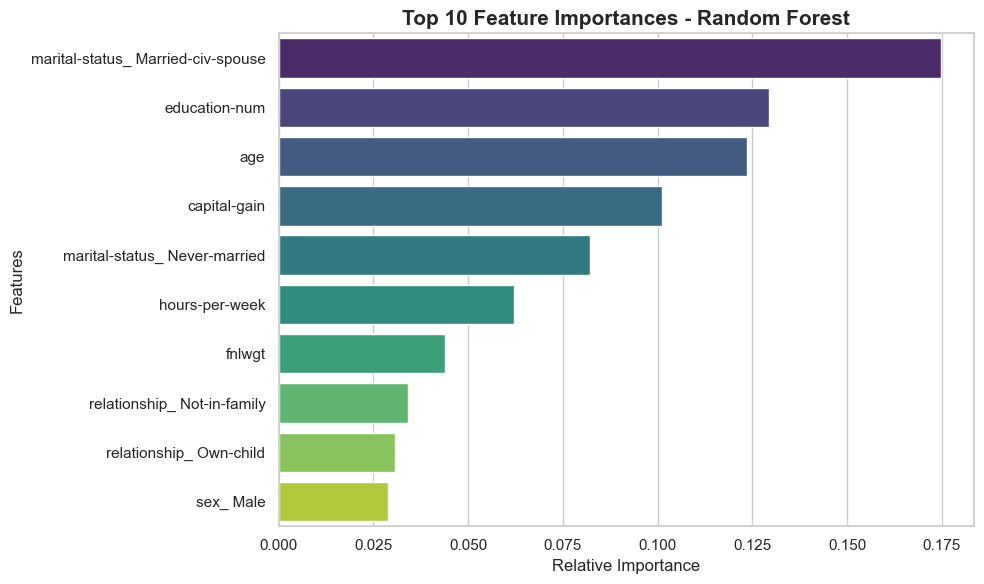

In [46]:
# 1. EXTRACT FEATURE IMPORTANCES
# Get importance scores directly from our tuned Random Forest model
importances = best_rf_model.feature_importances_

# 2. PREPARE DATA FOR VISUALIZATION
# Map the scores to their respective column names from the original 'X' dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort by importance and select the Top 10 most influential features
top_10_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. PLOT THE RESULTS
# Create a clean, professional bar chart for the portfolio
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_features, x='Importance', y='Feature', palette='viridis')

plt.title('Top 10 Feature Importances - Random Forest', fontsize=15, fontweight='bold')
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig('top_10_feature_importances.png', dpi=300, bbox_inches='tight') # YENİ EKLE
plt.show()